# Full operational experiment — Stage 1 calibration

This capstone asks one operational question: **which of four cumulative uncertainty methods produces the lowest all-in cost during the February 2016 calibration period?** The ANN forecasting model, 95% probability, opening stock, demand, policy, schedules, callbacks, constraints, and cost rates stay fixed. Only the construction of the four-day cumulative target changes.

All 100 M5 item series participate. M5 contributes demand observations and descriptive identifiers only. Every inventory, supplier, priority, intervention, and cost input is a transparent hypothetical tutorial assumption. Stage 1 selects one method on calibration data; demand from 2016-02-29 onward remains untouched for a later Stage 2 review.

## 1. Load the tools used at the forecast–inventory boundary

This cell establishes the exact forecasting environment and imports the Pyforia components that will own inventory timing, callbacks, constraints, event evidence, and evaluation. Smooth remains an external forecaster. The printed versions make the optional forecasting environment inspectable before any model is fitted.

In [1]:
from pathlib import Path
import importlib.metadata as metadata
import platform

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from scipy.stats import norm
from smooth import ES

from pyforia import (
    InventoryAdjustmentResult, InventoryStateDataFrame, MaximumOrderQuantity,
    MinimumOrderQuantity, OrderAdjustmentResult, OrderingConstraints,
    OrderMultiple, OrderUpToPolicy, SimulationCallback, SimulationEngine,
)
from pyforia.evaluation.inventory_evaluator import InventoryEvaluator
from pyforia.evaluation.metrics import (
    avg_on_hand, demand_period_service_level, demand_units, fill_rate,
    holding_cost, lost_sales_units, order_event_count, order_units,
    ordering_cost, peak_ending_on_hand, purchase_cost, shortage_cost,
    sku_order_line_count, total_cost,
)

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
smooth_version = metadata.version('smooth')
print(f'Python {platform.python_version()} | smooth {smooth_version}')

Python 3.10.12 | smooth 1.0.3


The version line is part of the experiment evidence. In particular, Smooth 1.0.7 does not make the simulated interval reproducible through a public seed parameter, so that method will be explicitly recorded as unseeded.

## 2. Read the complete prepared portfolio once

The local prepared table is consumed directly and sorted into 100 independent daily series. The preview confirms the identifier, calendar, demand, and descriptive fields. No category is used by the forecast model, and no item is removed or pooled before fitting.

In [2]:
data_path = Path('examples/notebooks/data/m5/sample_1.csv')

# Parse the business date before enforcing the per-SKU chronology.
demand_all = pd.read_csv(data_path, parse_dates=['date'])
demand_all = demand_all.sort_values(['unique_id', 'date']).reset_index(drop=True)

# Keep the full prepared portfolio; Smooth will receive one SKU at a time.
skus = sorted(demand_all['unique_id'].unique())

# One hundred independent daily series with no missing SKU-dates.
assert len(skus) == 100
assert demand_all.groupby('unique_id').size().nunique() == 1
assert demand_all[['unique_id', 'date']].duplicated().sum() == 0

print(f'Portfolio: {len(skus)} SKUs, {demand_all.date.nunique()} dates, {len(demand_all):,} rows')
demand_all.head(4)


Portfolio: 100 SKUs, 1913 dates, 191,300 rows


,unique_id,date,y,cat_id,dept_id,store_id,state_id
0,FOODS_1_001_CA_1,2011-01-29,3,FOODS,FOODS_1,CA_1,CA
1,FOODS_1_001_CA_1,2011-01-30,0,FOODS,FOODS_1,CA_1,CA
2,FOODS_1_001_CA_1,2011-01-31,0,FOODS,FOODS_1,CA_1,CA
3,FOODS_1_001_CA_1,2011-02-01,1,FOODS,FOODS_1,CA_1,CA


The compact preview shows the table that supplies demand observations. The 100-SKU count is the population used everywhere below; descriptive M5 columns do not become inventory inputs.

## 3. Freeze chronology and experiment windows before fitting

Training history is available through 2016-01-31. At each February origin, the information set expands only through that origin; the following four days provide that origin's cumulative calibration realization. The inventory replay begins on February 1 with four warm-up days, scores February 5–24, and settles February 25–28. The later final-test slice is named only to reserve its boundary—it is not used below.

In [3]:
period_frequency = 'D'
lead_time, review_period, probability = 2, 2, 0.95
protection_horizon = lead_time + review_period

training_end = pd.Timestamp('2016-01-31')
calibration_origins = pd.date_range('2016-02-02', '2016-02-24', freq='2D')
calibration_demand = demand_all[demand_all.date.between('2016-02-01', '2016-02-28')].copy()
final_test_demand = demand_all[demand_all.date.ge('2016-02-29')].copy()

# Engine demand periods are zero-based offsets from the first replay date.
calibration_demand['period'] = (calibration_demand['date'] - pd.Timestamp('2016-02-01')).dt.days

warmup_periods, scoring_periods, settlement_periods = 4, 20, 4
schedule_origins = calibration_origins[calibration_origins <= pd.Timestamp('2016-02-20')]
opening_date, opening_on_hand = training_end, 20.0
random_seed = None  # Observed demand is shared; no demand generator is called.

print(f'Forecast origins: {calibration_origins[0].date()} to {calibration_origins[-1].date()} ({len(calibration_origins)})')
print(f'Calibration replay: {calibration_demand.date.min().date()} to {calibration_demand.date.max().date()}')
print(f'Untouched final test begins: {final_test_demand.date.min().date()}')
# Twelve review-aligned origins; schedules stop February 20 so orders can land in scoring.
assert len(calibration_origins) == 12
assert schedule_origins.max() == pd.Timestamp('2016-02-20')
assert final_test_demand.date.min() == pd.Timestamp('2016-02-29')


Forecast origins: 2016-02-02 to 2016-02-24 (12)
Calibration replay: 2016-02-01 to 2016-02-28
Untouched final test begins: 2016-02-29


The twelve origins are aligned with the two-day review clock. Updates stop on February 20 even though forecast diagnostics continue through February 24; this gives accepted replenishment time to affect scoring before the four settlement days. The February 29 boundary is later than every fit, realization horizon, and replay date.

## 4. See the portfolio and its information boundaries

The upper panel summarizes total observed demand without collapsing the later modelling into one aggregate series. The lower timeline separates fixed training history, rolling calibration, the 28-day operational replay, and the untouched final test. This figure makes the leakage guard visible before the first fit.

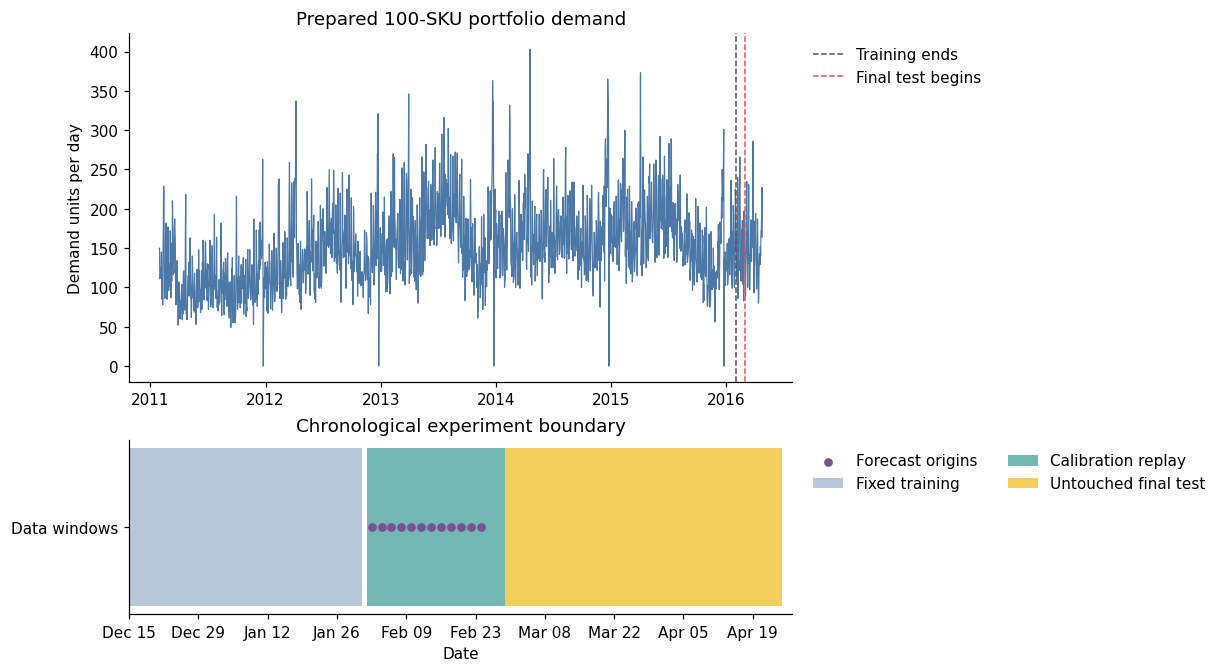

In [4]:
portfolio_daily = demand_all.groupby('date', as_index=False)['y'].sum()
fig, axes = plt.subplots(2, 1, figsize=(11, 6), gridspec_kw={'height_ratios': [2, 1]}, layout='constrained')

axes[0].plot(portfolio_daily.date, portfolio_daily.y, color='#4C78A8', lw=0.8)
axes[0].axvline(training_end, color='#555555', ls='--', lw=1, label='Training ends')
axes[0].axvline(pd.Timestamp('2016-02-29'), color='#E45756', ls='--', lw=1, label='Final test begins')
axes[0].set(title='Prepared 100-SKU portfolio demand', ylabel='Demand units per day')
axes[0].legend(frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1))

axes[1].barh('Data windows', (training_end - demand_all.date.min()).days, left=demand_all.date.min(), color='#B8C7D9', label='Fixed training')
axes[1].barh('Data windows', 28, left=pd.Timestamp('2016-02-01'), color='#72B7B2', label='Calibration replay')
axes[1].barh('Data windows', (demand_all.date.max() - pd.Timestamp('2016-02-29')).days + 1, left=pd.Timestamp('2016-02-29'), color='#F2CF5B', label='Untouched final test')
axes[1].scatter(calibration_origins, ['Data windows'] * len(calibration_origins), color='#7A5195', s=22, zorder=3, label='Forecast origins')
axes[1].set(xlabel='Date', title='Chronological experiment boundary')
axes[1].set_xlim(pd.Timestamp('2015-12-15'), demand_all.date.max() + pd.Timedelta(days=3))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[1].legend(frameon=False, ncol=2, loc='upper left', bbox_to_anchor=(1.01, 1))
plt.show()

The portfolio is intermittent and heterogeneous, which is why every model remains univariate and SKU-specific. The clustered purple origins sit wholly inside February calibration, while the yellow final-test region begins only after Stage 1 ends.

## 5. Declare the four cumulative uncertainty methods

All methods reuse the same fitted `ES(model="ANN")` object for a given SKU and origin. Smooth supplies the cumulative mean to every branch. Two branches request Smooth's cumulative upper bound directly; the other two use the fitted model's empirical multi-horizon error paths. The table records the exact scientific distinction before results are known.

In [5]:
method_order = [
    'Smooth approximate', 'Smooth simulated',
    'Empirical error paths', 'Covariance normal',
]
method_colors = {
    'Smooth approximate': '#4C78A8', 'Smooth simulated': '#F58518',
    'Empirical error paths': '#54A24B', 'Covariance normal': '#E45756',
}
method_design = pd.DataFrame({
    'method': method_order,
    'cumulative_uncertainty': [
        'Smooth approximate upper bound', 'Smooth simulated upper bound, nsim=100',
        '95th percentile of complete 4-step error-path sums',
        'normal approximation using empirical 4-horizon covariance',
    ],
    'simulation_seed': [None, None, None, None],
})
print(method_design.to_string(index=False))

               method                                    cumulative_uncertainty simulation_seed
   Smooth approximate                            Smooth approximate upper bound            None
     Smooth simulated                    Smooth simulated upper bound, nsim=100            None
Empirical error paths        95th percentile of complete 4-step error-path sums            None
    Covariance normal normal approximation using empirical 4-horizon covariance            None


The methods differ only in uncertainty construction. No branch sums marginal quantiles. `Smooth simulated` is visibly unseeded under the pinned release; the empirical and covariance branches use joint four-column error rows, preserving cross-horizon dependence information.

## 6. Fit one ANN model per SKU and origin, then reuse it four ways

This is the central forecasting operation. Each fit consumes that SKU's observations through the current origin and nothing later. The two Smooth calls request cumulative intervals directly. `rmultistep(h=4)` returns aligned four-horizon error rows: the empirical target takes the 95th percentile of each row's four-step sum, while the covariance target uses `sqrt(1ᵀΣ1)`. Every target and provenance field is retained without rounding, clipping, or replacement.

In [6]:
forecast_records, fit_records = [], []

for origin in calibration_origins:
    # This date filter is the leakage guard for every SKU fitted at this origin.
    available_history = demand_all[demand_all.date.le(origin)]

    for sku, sku_history in available_history.groupby('unique_id', sort=True):
        # Each SKU receives an independent ANN fit; no pooled state crosses series.
        training_series = sku_history['y'].astype(float).reset_index(drop=True)
        fitted_ann = ES(model='ANN').fit(training_series)
        fit_id = f'{origin.date()}::{sku}::ANN'

        # These are direct cumulative Smooth bounds, not sums of marginal bounds.
        approximate = fitted_ann.predict(
            h=protection_horizon, interval='approximate', level=probability,
            side='upper', cumulative=True,
        )
        simulated = fitted_ann.predict(
            h=protection_horizon, interval='simulated', level=probability,
            side='upper', cumulative=True, nsim=100,
        )

        # Whole multi-horizon error rows retain dependence across the four steps.
        error_paths = fitted_ann.rmultistep(h=protection_horizon).astype(float)
        path_sums = error_paths.sum(axis=1).to_numpy()
        error_covariance = np.cov(error_paths.to_numpy(), rowvar=False, ddof=1)
        cumulative_mean = float(approximate.mean.iloc[-1])
        empirical_safety = float(np.quantile(path_sums, probability))
        covariance_variance = float(np.ones(protection_horizon) @ error_covariance @ np.ones(protection_horizon))
        covariance_safety = float(norm.ppf(probability) * np.sqrt(covariance_variance))

        fit_records.append({
            'fit_id': fit_id, 'unique_id': sku, 'forecast_origin': origin,
            'observed_through_date': sku_history.date.max(),
            'history_rows': len(training_series), 'ets_model': 'ANN',
        })

        common = {
            'fit_id': fit_id, 'unique_id': sku, 'forecast_origin': origin,
            'observed_through_date': sku_history.date.max(),
            'forecast_frequency': period_frequency, 'protection_horizon': protection_horizon,
            'target_end_date': origin + pd.Timedelta(days=protection_horizon),
            'target_probability': probability, 'cumulative_mean': cumulative_mean,
            'ets_model': 'ANN', 'smooth_version': smooth_version,
            'error_path_rows': len(error_paths), 'covariance_sum_variance': covariance_variance,
            'empirical_error_quantile': empirical_safety,
            'representation': 'direct_cumulative_upper_quantile',
            'policy_target_source': 'external_direct',
        }
        method_values = [
            ('Smooth approximate', float(approximate.upper.iloc[-1, 0]) - cumulative_mean, float(approximate.upper.iloc[-1, 0]), 'smooth cumulative approximate upper', None),
            ('Smooth simulated', float(simulated.upper.iloc[-1, 0]) - cumulative_mean, float(simulated.upper.iloc[-1, 0]), 'smooth cumulative simulated upper', 100),
            ('Empirical error paths', empirical_safety, cumulative_mean + empirical_safety, 'mean + q95(sum of complete error path)', None),
            ('Covariance normal', covariance_safety, cumulative_mean + covariance_safety, 'mean + norm.ppf(.95) * sqrt(1T Sigma 1)', None),
        ]
        for method, safety_stock, target, formula, nsim in method_values:
            forecast_records.append(common | {
                'method': method, 'safety_stock': safety_stock,
                'cumulative_target': target, 'target_formula': formula,
                'simulation_count': nsim, 'simulation_seed': None,
            })

fit_registry = pd.DataFrame(fit_records)
target_catalogue = pd.DataFrame(forecast_records)

# Invalid scientific outputs stop the experiment; no target is silently repaired.
assert np.isfinite(target_catalogue[['cumulative_mean', 'safety_stock', 'cumulative_target']]).all().all()
assert target_catalogue['cumulative_target'].ge(0).all()
print(f'Independent ANN fits: {len(fit_registry):,}')
print(target_catalogue.query('unique_id == @skus[0]').head(4).to_string(index=False))

Independent ANN fits: 1,200
                           fit_id        unique_id forecast_origin observed_through_date forecast_frequency  protection_horizon target_end_date  target_probability  cumulative_mean ets_model smooth_version  error_path_rows  covariance_sum_variance  empirical_error_quantile                   representation policy_target_source                method  safety_stock  cumulative_target                          target_formula  simulation_count simulation_seed
2016-02-02::FOODS_1_001_CA_1::ANN FOODS_1_001_CA_1      2016-02-02            2016-02-02                  D                   4      2016-02-06                0.95         2.578401       ANN          1.0.3             1827                 6.416712                  4.765937 direct_cumulative_upper_quantile      external_direct    Smooth approximate      4.328626           6.907027     smooth cumulative approximate upper               NaN            None
2016-02-02::FOODS_1_001_CA_1::ANN FOODS_1_001_CA_1      20

The fit count is 1,200: 100 SKUs × 12 origins. The four displayed rows share one `fit_id`, confirming that the forecasting model and information set are held fixed while uncertainty changes. The catalogue retains raw cumulative targets, formula labels, dates, probability, history cutoff, Smooth version, error-path count, and simulation settings.

## 7. Attach the future four-day realizations

Each target is evaluated against demand from origin + 1 through origin + 4. This cell creates those whole-path realizations once and joins the same value to all four methods. Pinball loss respects the 95% asymmetric scoring rule; coverage and under-target units provide complementary calibration evidence.

In [7]:
realization_records = []
for origin in calibration_origins:
    # The outcome window starts after the information date and spans exactly H days.
    outcome = demand_all[demand_all.date.between(
        origin + pd.Timedelta(days=1),
        origin + pd.Timedelta(days=protection_horizon),
    )]
    realized = outcome.groupby('unique_id', as_index=False)['y'].sum()
    realization_records.append(realized.assign(forecast_origin=origin))

cumulative_realizations = pd.concat(realization_records, ignore_index=True)
cumulative_realizations = cumulative_realizations.rename(columns={'y': 'realized_cumulative_demand'})
calibration_targets = target_catalogue.merge(
    cumulative_realizations, on=['unique_id', 'forecast_origin'], validate='many_to_one',
)

target_error = calibration_targets['realized_cumulative_demand'] - calibration_targets['cumulative_target']
calibration_targets['pinball_loss'] = np.where(
    target_error.ge(0), probability * target_error, (1 - probability) * -target_error,
)
calibration_targets['covered'] = target_error.le(0)
calibration_targets['under_target_units'] = target_error.clip(lower=0)
print(calibration_targets[['method', 'unique_id', 'forecast_origin', 'cumulative_target', 'realized_cumulative_demand']].head(8).to_string(index=False))

               method        unique_id forecast_origin  cumulative_target  realized_cumulative_demand
   Smooth approximate FOODS_1_001_CA_1      2016-02-02           6.907027                           6
     Smooth simulated FOODS_1_001_CA_1      2016-02-02           6.985838                           6
Empirical error paths FOODS_1_001_CA_1      2016-02-02           7.344338                           6
    Covariance normal FOODS_1_001_CA_1      2016-02-02           6.745018                           6
   Smooth approximate FOODS_1_002_CA_1      2016-02-02           3.956587                           4
     Smooth simulated FOODS_1_002_CA_1      2016-02-02           3.831824                           4
Empirical error paths FOODS_1_002_CA_1      2016-02-02           4.084099                           4
    Covariance normal FOODS_1_002_CA_1      2016-02-02           3.799221                           4


Each four-row method block now points to one shared realized total. The realization begins strictly after the fit cutoff, so the target–outcome comparison is chronological. These forecast scores support diagnosis; they do not select the winner by themselves.

## 8. Walk through one SKU across all origins

The first panel compares the shared cumulative mean and realized four-day demand with each method's target. The second isolates safety stock, defined as target minus cumulative mean. This makes clear that all four methods share the forecast location and differ only in their uncertainty allowance.

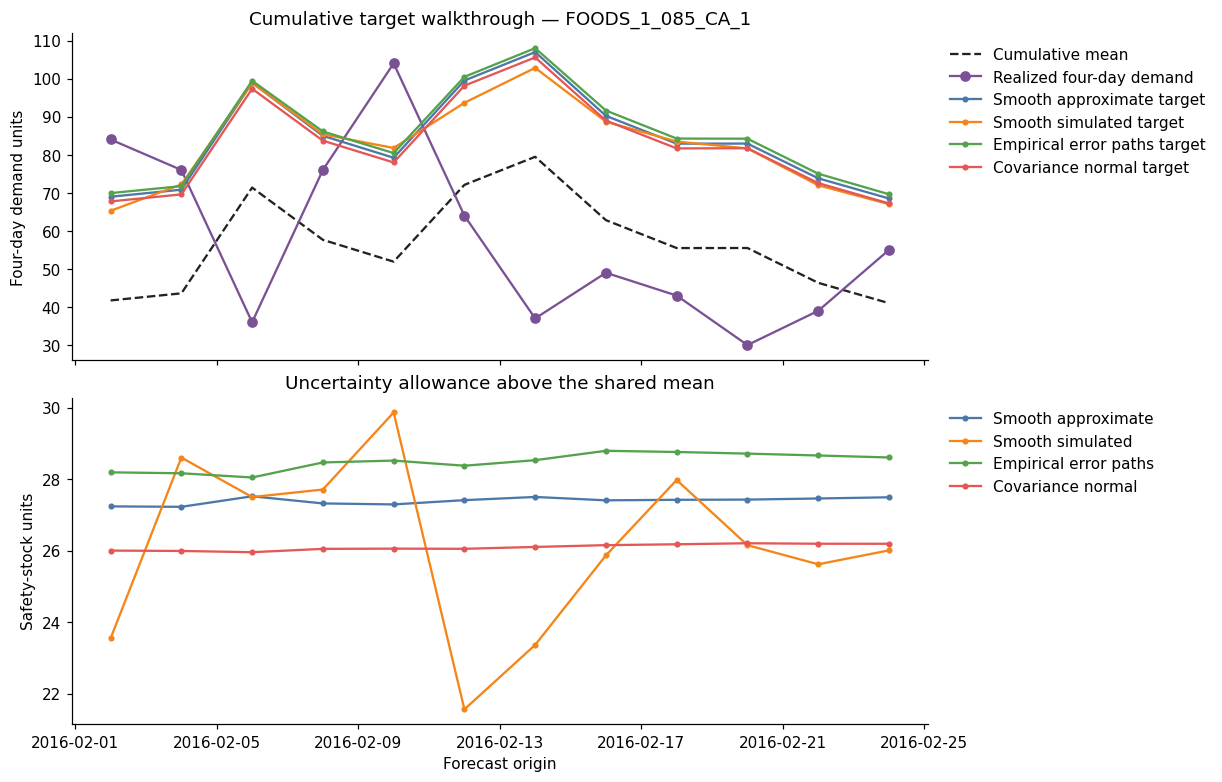

In [8]:
walkthrough_sku = 'FOODS_1_085_CA_1'
walkthrough = calibration_targets[calibration_targets.unique_id.eq(walkthrough_sku)].sort_values('forecast_origin')
shared_walkthrough = walkthrough.drop_duplicates('forecast_origin')

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, layout='constrained')
axes[0].plot(shared_walkthrough.forecast_origin, shared_walkthrough.cumulative_mean, color='#222222', ls='--', label='Cumulative mean')
axes[0].plot(shared_walkthrough.forecast_origin, shared_walkthrough.realized_cumulative_demand, color='#7A5195', marker='o', label='Realized four-day demand')
for method in method_order:
    rows = walkthrough[walkthrough.method.eq(method)]
    axes[0].plot(rows.forecast_origin, rows.cumulative_target, color=method_colors[method], marker='.', label=f'{method} target')
    axes[1].plot(rows.forecast_origin, rows.safety_stock, color=method_colors[method], marker='.', label=method)

axes[0].set(title=f'Cumulative target walkthrough — {walkthrough_sku}', ylabel='Four-day demand units')
axes[1].set(title='Uncertainty allowance above the shared mean', ylabel='Safety-stock units', xlabel='Forecast origin')
axes[0].legend(frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1))
axes[1].legend(frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1))
plt.show()

The realized path can cross some targets even when those methods add substantial safety stock. That is expected in a finite calibration sample: coverage, loss, and target height describe different trade-offs. The later inventory replay will determine which trade-off is least costly under the declared operating rules.

## 9. Compare forecast evidence without choosing a winner

This summary pools the same 1,200 SKU-origin outcomes per method. Pinball loss rewards an appropriately placed 95% quantile; coverage reports how often realized cumulative demand stayed below target; under-target units measure miss size; and mean target and safety stock show inventory pressure. None of these columns replaces the operational cost objective.

In [9]:
forecast_summary = calibration_targets.groupby('method', as_index=False).agg(
    mean_pinball_loss=('pinball_loss', 'mean'),
    coverage=('covered', 'mean'),
    mean_under_target_units=('under_target_units', 'mean'),
    mean_target_units=('cumulative_target', 'mean'),
    mean_safety_stock=('safety_stock', 'mean'),
)
forecast_summary['method'] = pd.Categorical(forecast_summary.method, method_order, ordered=True)
forecast_summary = forecast_summary.sort_values('method').reset_index(drop=True)
print(forecast_summary.to_string(index=False))

               method  mean_pinball_loss  coverage  mean_under_target_units  mean_target_units  mean_safety_stock
   Smooth approximate           0.722099  0.906667                 0.386278          12.868087           6.719891
     Smooth simulated           0.745311  0.902500                 0.421117          12.635563           6.487368
Empirical error paths           0.705384  0.915833                 0.373453          12.790296           6.642100
    Covariance normal           0.725363  0.902500                 0.410107          12.456773           6.308577


The table exposes the expected calibration trade-off: a method can improve coverage by carrying a higher target and still be unattractive operationally. Method selection remains deferred until the same policy and supplier system has priced stock, shortages, purchasing, ordering, and accepted interventions.

## 10. View all five forecast diagnostics on a common method palette

The compact panels repeat the preceding table visually so scale differences are easy to compare. Bars are categorical summaries, use the same method order and colors throughout the notebook, and retain ordinary demand-unit labels rather than normalized or logarithmic encodings.

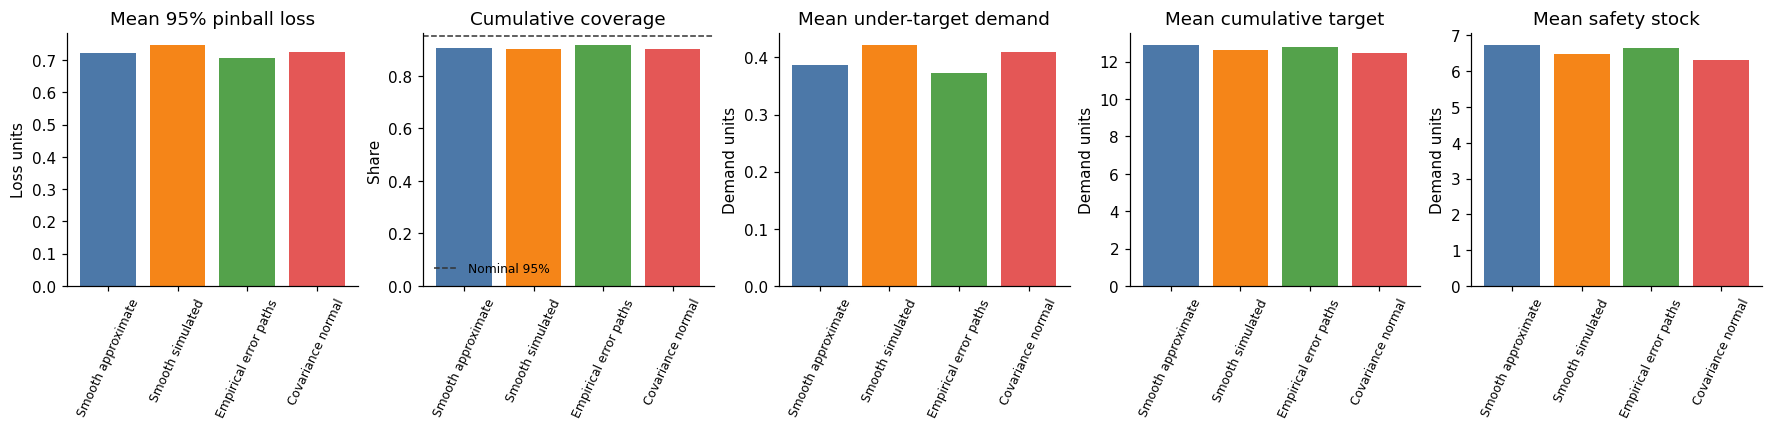

In [10]:
forecast_panels = [
    ('mean_pinball_loss', 'Mean 95% pinball loss', 'Loss units'),
    ('coverage', 'Cumulative coverage', 'Share'),
    ('mean_under_target_units', 'Mean under-target demand', 'Demand units'),
    ('mean_target_units', 'Mean cumulative target', 'Demand units'),
    ('mean_safety_stock', 'Mean safety stock', 'Demand units'),
]
fig, axes = plt.subplots(1, 5, figsize=(16, 3.8), layout='constrained')
for ax, (column, title, ylabel) in zip(axes, forecast_panels):
    ax.bar(forecast_summary.method.astype(str), forecast_summary[column], color=[method_colors[m] for m in method_order])
    ax.set(title=title, ylabel=ylabel)
    ax.tick_params(axis='x', rotation=65, labelsize=8)
    if column == 'coverage':
        ax.axhline(probability, color='#333333', ls='--', lw=1, label='Nominal 95%')
        ax.legend(frameon=False, fontsize=8, loc='lower left')
plt.show()

The panels make the cost question unavoidable: stronger empirical coverage generally comes with larger cumulative targets and safety stocks. The operational replay below will expose whether shortage avoidance offsets those additional stock and purchase consequences.

## 11. Check per-SKU heterogeneity

Portfolio means can conceal methods that help some items and hurt others. This cell first calculates each SKU's mean pinball loss and coverage across the twelve origins, then plots their distributions. The same 100 identifiers appear in every method group.

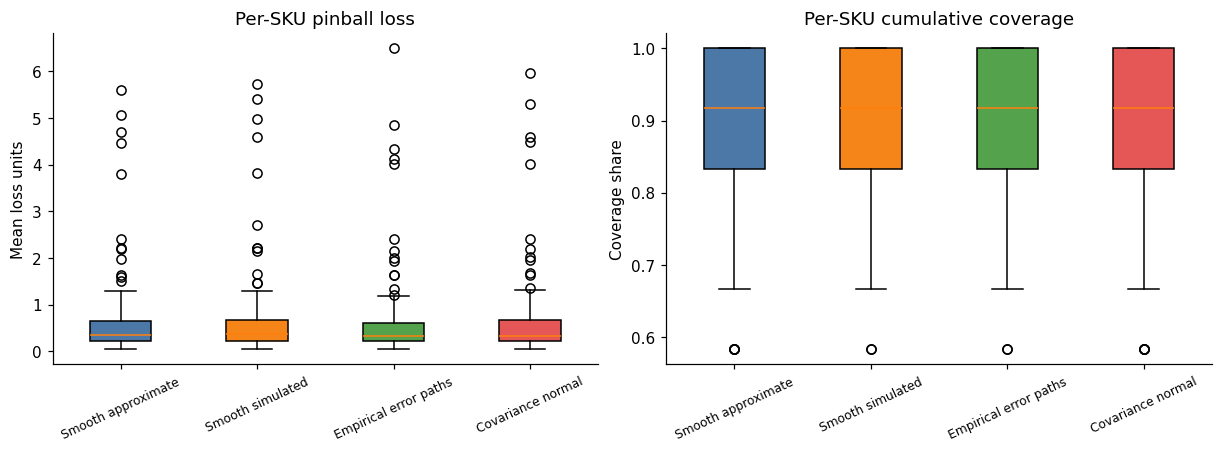

In [11]:
sku_forecast_evidence = calibration_targets.groupby(['method', 'unique_id'], as_index=False).agg(
    mean_pinball_loss=('pinball_loss', 'mean'),
    coverage=('covered', 'mean'),
    mean_target_units=('cumulative_target', 'mean'),
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
for ax, column, title, ylabel in [
    (axes[0], 'mean_pinball_loss', 'Per-SKU pinball loss', 'Mean loss units'),
    (axes[1], 'coverage', 'Per-SKU cumulative coverage', 'Coverage share'),
]:
    groups = [sku_forecast_evidence.loc[sku_forecast_evidence.method.eq(method), column] for method in method_order]
    boxes = ax.boxplot(groups, tick_labels=method_order, patch_artist=True)
    for patch, method in zip(boxes['boxes'], method_order):
        patch.set_facecolor(method_colors[method])
    ax.set(title=title, ylabel=ylabel)
    ax.tick_params(axis='x', rotation=25, labelsize=8)
plt.show()

The spread confirms that one portfolio average is not a universal SKU-level result. Stage 1 nevertheless uses the predeclared pooled all-in cost objective, so heterogeneity remains supporting evidence rather than an after-the-fact selection rule.

## 12. Fit dated Pyforia policy snapshots directly

Each method needs a compatible `(R,S)` snapshot at every eligible update date. The loop below calls `OrderUpToPolicy.fit` directly on the complete cumulative target, never on safety stock. Schedule keys 2 through 20 correspond exactly to February 2 through February 20. A declared, unused opening fallback satisfies engine preflight; period 2 is always replaced by the first dated schedule snapshot before any order is requested.

In [12]:
base_policies, policy_schedules = [], []
base_target_table = pd.DataFrame({
    'unique_id': skus, 'cumulative_target': opening_on_hand,
    'target_end_date': opening_date + pd.Timedelta(days=protection_horizon),
})

for method in method_order:
    # The base policy is a preflight fallback and is never used at a decision event.
    base_policy = OrderUpToPolicy(
        lead_time=lead_time, review_period=review_period,
        service_level=probability, allow_backorders=False,
    ).fit(
        base_target_table, forecast_origin=opening_date,
        forecast_frequency=period_frequency, target_column='cumulative_target',
        target_end_date_column='target_end_date', target_probability=probability,
        protection_horizon=protection_horizon, target_source='external_direct',
    )

    method_schedule = {}
    for origin in schedule_origins:
        # The engine period and policy origin identify the same review decision date.
        decision_period = int((origin - opening_date).days)
        dated_targets = target_catalogue[
            target_catalogue.method.eq(method) & target_catalogue.forecast_origin.eq(origin)
        ][['unique_id', 'cumulative_target', 'target_end_date']]
        method_schedule[decision_period] = OrderUpToPolicy(
            lead_time=lead_time, review_period=review_period,
            service_level=probability, allow_backorders=False,
        ).fit(
            dated_targets, forecast_origin=origin,
            forecast_frequency=period_frequency, target_column='cumulative_target',
            target_end_date_column='target_end_date', target_probability=probability,
            protection_horizon=protection_horizon, target_source='external_direct',
        )

    base_policies.append(base_policy)
    policy_schedules.append(method_schedule)

schedule_evidence = pd.DataFrame({
    'method': method_order,
    'update_periods': [list(schedule) for schedule in policy_schedules],
    'last_update_date': [opening_date + pd.Timedelta(days=max(schedule)) for schedule in policy_schedules],
})
print(schedule_evidence.to_string(index=False))

               method                       update_periods last_update_date
   Smooth approximate [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]       2016-02-20
     Smooth simulated [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]       2016-02-20
Empirical error paths [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]       2016-02-20
    Covariance normal [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]       2016-02-20


All four schedules have the same ten decision periods and stop on February 20. Policy class, lead time, review period, service metadata, lost-sales mode, and frequency are identical. Only each snapshot's complete fitted target table changes.

## 13. Priority expedite callback

This callback answers whether a predeclared priority SKU with low inventory position needs its current proposal raised to 25 units. It runs after the policy predicts and before the supplier gate. The returned quantity is an absolute proposal, and a `None` path means the current composed decision proceeds unchanged.

In [13]:
class PriorityExpedite(SimulationCallback):
    """Raise an eligible priority line to one declared expedite quantity."""

    def __init__(self, priority_skus, inventory_position_threshold, expedite_quantity, reason, source):
        self.priority_skus = list(priority_skus)
        self.inventory_position_threshold = float(inventory_position_threshold)
        self.expedite_quantity = float(expedite_quantity)
        self.reason = reason
        self.source = source

    def on_after_prediction(self, decision, context):
        # The decision and inventory in callback context are defensive views.
        proposed = decision.get_dataframe()[['unique_id', 'order_quantity']].copy()
        state = context.inventory.set_index(context.sku_column)
        inventory_position = (
            state['on_hand']
            + state['in_transit'].map(lambda values: float(np.sum(values)))
            - state['backorders']
        )
        proposed['inventory_position'] = proposed['unique_id'].map(inventory_position)

        # Priority and threshold are fixed inputs, never inferred from calibration outcomes.
        eligible = proposed[
            proposed['unique_id'].isin(self.priority_skus)
            & proposed['inventory_position'].lt(self.inventory_position_threshold)
            & proposed['order_quantity'].lt(self.expedite_quantity)
        ].copy()
        if eligible.empty:
            return None

        eligible['order_quantity'] = self.expedite_quantity
        eligible['reason'] = self.reason
        eligible['source'] = self.source
        return OrderAdjustmentResult(
            eligible[['unique_id', 'order_quantity', 'reason', 'source']]
        )

    def get_config(self):
        return {
            'priority_skus': self.priority_skus,
            'inventory_position_threshold': self.inventory_position_threshold,
            'expedite_quantity': self.expedite_quantity,
            'reason': self.reason,
            'source': self.source,
        }

The class carries only explicit configuration and no accumulated run state. This matters because `run_comparison` resets and reuses the callback across isolated branches; accepted effects are retained in each branch's callback audit.

## 14. Supplier batch gate callback

The supplier rule applies to the complete positive portfolio proposal after priority expediting. If combined proposed units are below 100, every positive line is held at zero for that review. Rejected quantities are not accumulated in callback state; the policy recalculates later from then-current inventory.

In [14]:
class SupplierBatchGate(SimulationCallback):
    """Hold a positive supplier panel that misses the declared batch minimum."""

    def __init__(self, minimum_batch_units, reason, source):
        self.minimum_batch_units = float(minimum_batch_units)
        self.reason = reason
        self.source = source

    def on_after_prediction(self, decision, context):
        # The gate sees the complete decision composed by earlier callbacks.
        proposed = decision.get_dataframe()
        positive = proposed.loc[
            proposed['order_quantity'].gt(0), ['unique_id', 'order_quantity']
        ].copy()
        if positive.empty:
            return None
        if positive['order_quantity'].sum() >= self.minimum_batch_units:
            return None

        positive['order_quantity'] = 0.0
        positive['reason'] = self.reason
        positive['source'] = self.source
        return OrderAdjustmentResult(
            positive[['unique_id', 'order_quantity', 'reason', 'source']]
        )

    def get_config(self):
        return {
            'minimum_batch_units': self.minimum_batch_units,
            'reason': self.reason,
            'source': self.source,
        }

Returning `None` leaves an acceptable panel untouched; returning typed zero quantities records an accepted gate intervention. Supplier overhead later prices only final positive portfolio order events, so a held panel cannot create a supplier-event cost.

## 15. Receiving-inspection breakage callback

This physical adjustment runs after daily demand and before that day's order decision. It removes 2% of units received that day, limited explicitly to post-demand on-hand because the callback phase cannot remove stock already consumed. A day with no feasible removal returns `None`; every accepted unit is signed and audited.

In [15]:
class ReceivingInspectionBreakage(SimulationCallback):
    """Remove a declared share of receipts from post-demand on-hand."""

    def __init__(self, loss_fraction, reason, source):
        self.loss_fraction = float(loss_fraction)
        self.reason = reason
        self.source = source

    def on_after_demand(self, context):
        # Receipts arrived before demand; on_hand is the feasible stock remaining afterward.
        received = context.inventory.loc[
            context.inventory['latest_received'].gt(0),
            [context.sku_column, 'latest_received', 'on_hand'],
        ].copy()
        if received.empty:
            return None

        # The phase-feasible loss is explicit; the engine would reject negative stock.
        received['removed_units'] = np.minimum(
            self.loss_fraction * received['latest_received'], received['on_hand'],
        )
        received = received[received['removed_units'].gt(0)].copy()
        if received.empty:
            return None

        received['quantity_delta'] = -received['removed_units']
        received['reason'] = self.reason
        received['source'] = self.source
        return InventoryAdjustmentResult(
            received.rename(columns={context.sku_column: 'unique_id'})[[
                'unique_id', 'quantity_delta', 'reason', 'source',
            ]]
        )

    def get_config(self):
        return {
            'loss_fraction': self.loss_fraction,
            'phase_feasibility': 'minimum of receipt loss and post-demand on-hand',
            'reason': self.reason,
            'source': self.source,
        }

This is receiving-inspection breakage recorded after demand, not literal in-transit loss. Its complete configuration explains both the 2% rule and the phase-feasibility limit, while canonical event rows retain the accepted physical adjustment.

## 16. Assemble callback and constraint order

The order path is intentionally visible: `(R,S)` policy → priority expedite → supplier batch gate → MOQ → order multiple → maximum → accepted order. Receiving breakage belongs to the earlier after-demand phase. These objects are shared experiment inputs and the engine records their ordered configurations in every manifest.

In [16]:
priority_skus = ['FOODS_1_085_CA_1', 'FOODS_1_018_CA_1', 'FOODS_1_004_CA_1']
priority_expedite = PriorityExpedite(
    priority_skus, 8.0, 25.0,
    'priority item below declared inventory-position threshold',
    'hypothetical tutorial expedite rule',
)
supplier_batch_gate = SupplierBatchGate(
    100.0, 'positive supplier panel below declared batch minimum',
    'hypothetical tutorial batch rule',
)
receiving_breakage = ReceivingInspectionBreakage(
    0.02, 'receiving-inspection breakage recorded after daily demand',
    'hypothetical tutorial breakage rule',
)
callbacks = [priority_expedite, supplier_batch_gate, receiving_breakage]

# Constraint application order is scientifically material and manifest-recorded.
constraints = OrderingConstraints([
    MinimumOrderQuantity(3.0, mode='adjust'),
    OrderMultiple(5.0, mode='adjust'),
    MaximumOrderQuantity(30.0, mode='adjust'),
])
print('Callback order:', [type(callback).__name__ for callback in callbacks])
print('Constraint order:', [entry['class'] for entry in constraints.to_manifest()['constraints']])

Callback order: ['PriorityExpedite', 'SupplierBatchGate', 'ReceivingInspectionBreakage']
Constraint order: ['MinimumOrderQuantity', 'OrderMultiple', 'MaximumOrderQuantity']


The printed sequence is the configuration that every method receives. The compatible maximum of 30 is itself a multiple of 5 and exceeds the MOQ, so the final cross-validation can satisfy all three constraints after ordered adjustment.

## 17. Construct one explicit opening state

Every branch starts with 20 observed scenario units per SKU, zero backlog, and an empty two-slot pipeline on January 31. This is not inferred from M5 or from any forecast. `run_comparison` deep-copies this ready state for each branch, preventing stock or pipeline leakage across methods.

In [17]:
opening_table = pd.DataFrame({
    'unique_id': skus,
    'observed_on_hand': opening_on_hand,
})


In [18]:
calibration_inventory = InventoryStateDataFrame(
    skus, max_lead_time=lead_time, allow_backorders=False,
).initialize_from_observed(
    opening_table,
    on_hand_column='observed_on_hand',
    start_date=opening_date,
)

opening_preview = calibration_inventory.get_dataframe().head(4).copy()
opening_preview['in_transit'] = opening_preview['in_transit'].map(list)
print(opening_preview[['unique_id', 'on_hand', 'backorders', 'in_transit', 'period', 'date']].to_string(index=False))
calibration_inventory


       unique_id  on_hand  backorders in_transit  period       date
FOODS_1_001_CA_1     20.0         0.0 [0.0, 0.0]     0.0 2016-01-31
FOODS_1_002_CA_1     20.0         0.0 [0.0, 0.0]     0.0 2016-01-31
FOODS_1_003_CA_1     20.0         0.0 [0.0, 0.0]     0.0 2016-01-31
FOODS_1_004_CA_1     20.0         0.0 [0.0, 0.0]     0.0 2016-01-31


InventoryStateDataFrame(n_skus=100, total_on_hand=2000, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

The preview shows physical opening stock and timing coordinates directly. Orders will enter the pipeline at accepted review events; they cannot increase on-hand until the two-day lead time has elapsed.

## 18. Replay the four methods on one shared February demand path

This is the only comparison run in Stage 1. It consumes four fitted base policies, four method-specific schedules, one complete calibration demand grid, one opening state, one callback list, and one constraint chain. The engine owns the callback phase order, constraint application, accepted orders, lead-time pipeline, windows, and canonical validation.

In [19]:
comparison = SimulationEngine().run_comparison(
    policies=base_policies,
    policy_schedules=policy_schedules,
    labels=method_order,
    demand_source=calibration_demand,
    inventory=calibration_inventory,
    n_periods=len(calibration_demand) // len(skus),
    period_frequency=period_frequency,
    initial_decision='none',
    warmup_periods=warmup_periods,
    scoring_periods=scoring_periods,
    settlement_periods=settlement_periods,
    order_during_settlement=False,
    demand_source_name='local_prepared_m5_sample_1_february_2016_calibration',
    random_seed=random_seed,
    callbacks=callbacks,
    order_constraints=constraints,
)
print(comparison.summary().reset_index().to_string(index=False))

               policy  fill_rate  demand_period_service_level  mean_ending_on_hand_per_sku_period  stockout_periods  total_order_units  order_event_count  sku_order_line_count
   Smooth approximate   0.947104                     0.980024                            15.67205                 8             2810.0                 10                   280
     Smooth simulated   0.945817                     0.975323                            15.56220                10             2790.0                 10                   280
Empirical error paths   0.948713                     0.978848                            15.69855                 8             2810.0                 10                   277
    Covariance normal   0.945528                     0.978848                            15.50010                 8             2780.0                 10                   277


The four summaries come from isolated branches over one materialized demand frame. They already show service, end-of-period stock, and ordering differences, but selection waits for the complete scoring-window cost identity—including accepted intervention evidence.

## 19. Inspect the composed order trail

The event ledger is the accounting source of truth. This compact slice exposes policy request, callback-adjusted proposal, constraint-adjusted proposal, and final accepted quantity for one priority SKU. It also shows the target in force, inventory position, and binding constraints at the same dated review events.

In [20]:
trail_method = method_order[0]
trail_events = comparison[trail_method].to_event_frame(window='all')
order_trail = trail_events[
    trail_events.unique_id.eq(priority_skus[0]) & trail_events.is_review_period
][[
    'date', 'run_window', 'target_level', 'inventory_position_end',
    'requested_order_quantity', 'callback_adjusted_order_quantity',
    'constrained_order_quantity', 'order_quantity', 'binding_constraints',
]]
print(order_trail.head(10).to_string(index=False))

      date run_window  target_level  inventory_position_end  requested_order_quantity  callback_adjusted_order_quantity  constrained_order_quantity  order_quantity                   binding_constraints
2016-02-02     warmup     68.966197                    34.0                 64.966197                         64.966197                        30.0            30.0 order_multiple|maximum_order_quantity
2016-02-04     warmup     70.815001                    49.4                 51.415001                         51.415001                        30.0            30.0 order_multiple|maximum_order_quantity
2016-02-06    scoring     98.890427                    30.0                 98.890427                         98.890427                        30.0            30.0 order_multiple|maximum_order_quantity
2016-02-08    scoring     84.964125                    49.4                 65.564125                         65.564125                        30.0            30.0 order_multiple|maximum_order

The columns follow the declared sequence without reconstructing decisions from policy state. Schedule targets remain active after the February 20 update; decisions stop entirely in settlement because `order_during_settlement=False`.

## 20. Calculate ordinary evaluator costs

The first cost layer prices only validated scoring rows with Pyforia's ordinary cost API. Holding is 0.02 per ending unit-period, shortage is 2.00 per lost unit, ordering is 0.50 per positive SKU line, and purchase is 1.00 per accepted unit. The evaluator receives an explicit scoring window, pooled grouping, named components, and every active rate.

In [21]:
cost_context = {
    'cost_components': ['holding', 'shortage', 'ordering', 'purchase'],
    'holding_cost_per_unit_period': 0.02,
    'shortage_cost_per_unit': 2.00,
    'order_cost_per_sku_line': 0.50,
    'order_cost_per_unit': 0.00,
    'purchase_cost_per_unit': 1.00,
}
operational_metrics = [
    demand_units, fill_rate, demand_period_service_level, lost_sales_units,
    avg_on_hand, peak_ending_on_hand, order_units, sku_order_line_count,
    order_event_count, holding_cost, shortage_cost, ordering_cost,
    purchase_cost, total_cost,
]

ordinary_rows = []
for method in method_order:
    evaluated = InventoryEvaluator().fit(
        simulation_result=comparison[method], window='scoring',
    ).evaluate(operational_metrics, groupby=[], context=cost_context)
    ordinary_rows.append(evaluated.iloc[0].to_dict() | {'method': method})

ordinary_costs = pd.DataFrame(ordinary_rows)
print(ordinary_costs[['method', 'holding_cost', 'shortage_cost', 'ordering_cost', 'purchase_cost', 'total_cost']].to_string(index=False))

               method  holding_cost  shortage_cost  ordering_cost  purchase_cost  total_cost
   Smooth approximate       626.882          328.8          140.0         2810.0    3905.682
     Smooth simulated       622.488          336.8          140.0         2790.0    3889.288
Empirical error paths       627.942          318.8          138.5         2810.0    3895.242
    Covariance normal       620.004          338.6          138.5         2780.0    3877.104


`total_cost` is exactly the sum of the four displayed ordinary components. It does not yet include expedite, supplier-event, or breakage charges; those require accepted callback and event evidence and are therefore assembled separately.

## 21. Price accepted expedite triggers

An expedite is priced only when the callback audit records a quantity increase during scoring **and** the canonical event retains a positive final accepted order for that SKU and period. This prevents a later supplier hold from being charged as an accepted trigger. The cost is 3.00 per retained trigger.

In [22]:
expedite_rows = []
accepted_expedite_evidence = {}
for method in method_order:
    scoring_events = comparison[method].to_event_frame(window='scoring')
    callback_audit = comparison[method].to_callback_audit_frame()
    proposed = callback_audit[
        callback_audit.callback_class.eq('PriorityExpedite')
        & callback_audit.run_window.eq('scoring')
        & callback_audit.after_value.gt(callback_audit.before_value)
    ][[
        'unique_id', 'period', 'date', 'before_value', 'after_value',
        'reason', 'source',
    ]]
    accepted = proposed.merge(
        scoring_events[['unique_id', 'period', 'date', 'order_quantity']],
        on=['unique_id', 'period', 'date'], validate='one_to_one',
    )
    accepted = accepted[accepted.order_quantity.gt(0)].copy()
    accepted_expedite_evidence[method] = accepted
    trigger_count = int(len(accepted))
    expedite_rows.append({'method': method, 'accepted_expedite_triggers': trigger_count, 'expedite_cost': 3.00 * trigger_count})

expedite_costs = pd.DataFrame(expedite_rows)
print(expedite_costs.to_string(index=False))

               method  accepted_expedite_triggers  expedite_cost
   Smooth approximate                           0            0.0
     Smooth simulated                           0            0.0
Empirical error paths                           0            0.0
    Covariance normal                           0            0.0


The trigger counts are derived from matched audit and final-event rows, not from callback configuration or a hypothetical opportunity count. Thus every charged expedite has dated, SKU-level accepted evidence.

## 22. Price accepted supplier order events

Pyforia stores one system `order_event_count` on a single event row per positive decision period so that summing remains additive. This cell counts those accepted positive portfolio events in scoring and charges 2.00 each. A supplier batch held at zero contributes no event and no overhead.

In [23]:
supplier_rows = []
accepted_supplier_evidence = {}
for method in method_order:
    scoring_events = comparison[method].to_event_frame(window='scoring')
    by_date = scoring_events.groupby('date', as_index=False).agg(
        accepted_portfolio_order_units=('order_quantity', 'sum'),
        accepted_supplier_events=('order_event_count', 'sum'),
    )
    accepted = by_date[by_date.accepted_portfolio_order_units.gt(0)].copy()
    accepted_supplier_evidence[method] = accepted
    event_count = int(accepted.accepted_supplier_events.sum())
    supplier_rows.append({'method': method, 'accepted_supplier_events': event_count, 'supplier_overhead_cost': 2.00 * event_count})

supplier_costs = pd.DataFrame(supplier_rows)
print(supplier_costs.to_string(index=False))

               method  accepted_supplier_events  supplier_overhead_cost
   Smooth approximate                        10                    20.0
     Smooth simulated                        10                    20.0
Empirical error paths                        10                    20.0
    Covariance normal                        10                    20.0


The accepted event count is portfolio-level rather than 100 repeated SKU charges. It prices only final positive order events after both callbacks and all three constraints.

## 23. Price accepted post-demand breakage

Breakage cost comes from accepted negative inventory adjustments in the callback audit during scoring. Negating the signed deltas yields removed physical units; the matching event sum is checked later. Each accepted removed unit costs 0.25.

In [24]:
breakage_rows = []
accepted_breakage_evidence = {}
for method in method_order:
    callback_audit = comparison[method].to_callback_audit_frame()
    accepted = callback_audit[
        callback_audit.callback_class.eq('ReceivingInspectionBreakage')
        & callback_audit.run_window.eq('scoring')
        & callback_audit.quantity_delta.lt(0)
    ].copy()
    accepted_breakage_evidence[method] = accepted
    removed_units = float(-accepted.quantity_delta.sum())
    breakage_rows.append({'method': method, 'accepted_breakage_units': removed_units, 'breakage_cost': 0.25 * removed_units})

breakage_costs = pd.DataFrame(breakage_rows)
print(breakage_costs.to_string(index=False))

               method  accepted_breakage_units  breakage_cost
   Smooth approximate                     54.5         13.625
     Smooth simulated                     53.9         13.475
Empirical error paths                     54.1         13.525
    Covariance normal                     53.9         13.475


These units were physically removed after demand and are visible both in the accepted callback audit and the canonical inventory-adjustment flow. The intervention price remains separate from ordinary shortage and purchase costs.

## 24. Assemble all-in cost and select Stage 1's method

The predeclared selector is the minimum all-in scoring cost. This cell joins the four ordinary components and three intervention components, checks their additive identity, divides by common scoring demand, and freezes the lowest-cost method. Pinball loss, coverage, service, stock, shortages, and ordering remain supporting evidence rather than tie-breakers.

In [25]:
all_in_costs = (
    ordinary_costs
    .merge(expedite_costs, on='method', validate='one_to_one')
    .merge(supplier_costs, on='method', validate='one_to_one')
    .merge(breakage_costs, on='method', validate='one_to_one')
)
cost_components = [
    'holding_cost', 'shortage_cost', 'ordering_cost', 'purchase_cost',
    'expedite_cost', 'supplier_overhead_cost', 'breakage_cost',
]
all_in_costs['all_in_total_cost'] = all_in_costs[cost_components].sum(axis=1)
all_in_costs['cost_per_demand_unit'] = all_in_costs['all_in_total_cost'] / all_in_costs['demand_units']
all_in_costs = all_in_costs.merge(forecast_summary, on='method', validate='one_to_one')
all_in_costs['method'] = pd.Categorical(all_in_costs.method, method_order, ordered=True)

selection_ranking = all_in_costs.sort_values(['all_in_total_cost', 'method']).reset_index(drop=True)
selected_method = str(selection_ranking.iloc[0]['method'])
print(selection_ranking[[
    'method', 'all_in_total_cost', 'cost_per_demand_unit', 'mean_pinball_loss',
    'coverage', 'fill_rate', 'lost_sales_units', 'avg_on_hand', 'order_units',
]].to_string(index=False))
print(f'\nStage 1 selection: {selected_method} — minimum calibration all-in cost')

               method  all_in_total_cost  cost_per_demand_unit  mean_pinball_loss  coverage  fill_rate  lost_sales_units  avg_on_hand  order_units
    Covariance normal           3910.579              1.258230           0.725363  0.902500   0.945528             169.3     15.50010       2780.0
     Smooth simulated           3922.763              1.262150           0.745311  0.902500   0.945817             168.4     15.56220       2790.0
Empirical error paths           3928.767              1.264082           0.705384  0.915833   0.948713             159.4     15.69855       2810.0
   Smooth approximate           3939.307              1.267473           0.722099  0.906667   0.947104             164.4     15.67205       2810.0

Stage 1 selection: Covariance normal — minimum calibration all-in cost


The selected method wins only under this displayed February calibration experiment and normalized cost system. Cost per demand unit makes the portfolio scale explicit. Forecast and service columns help explain the result, but they do not alter the minimum-cost rule.

## 25. Show every cost component

The stacked bars preserve all seven components instead of hiding interventions inside a residual total. A method with higher protection can trade shortage cost for purchase and holding cost; callbacks and supplier events add their own evidence-based layers.

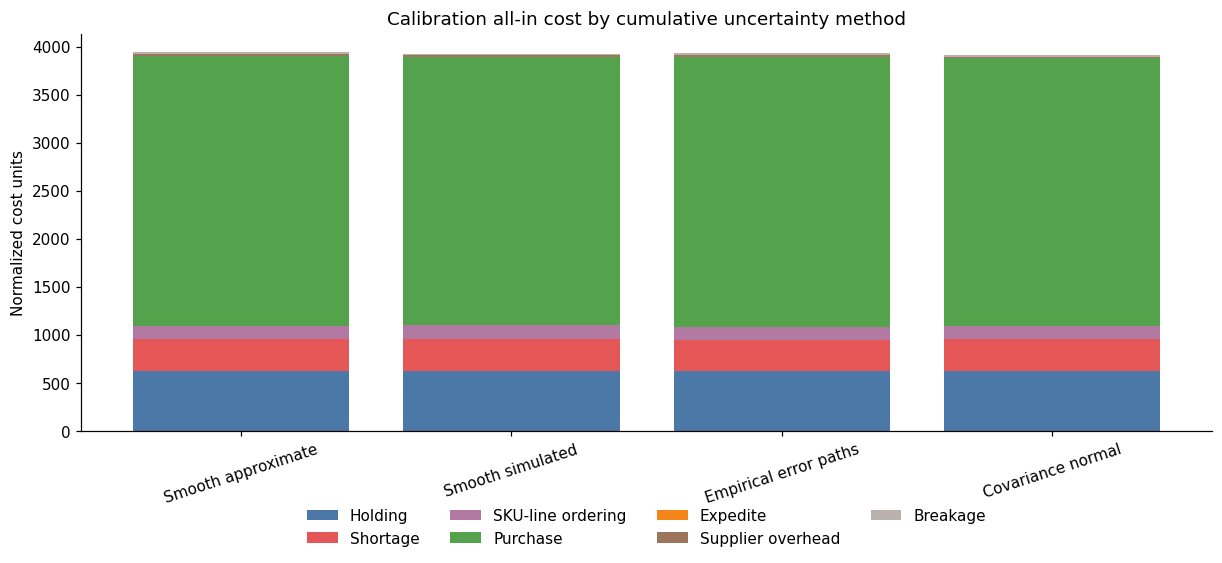

In [26]:
cost_labels = {
    'holding_cost': 'Holding', 'shortage_cost': 'Shortage',
    'ordering_cost': 'SKU-line ordering', 'purchase_cost': 'Purchase',
    'expedite_cost': 'Expedite', 'supplier_overhead_cost': 'Supplier overhead',
    'breakage_cost': 'Breakage',
}
component_colors = ['#4C78A8', '#E45756', '#B279A2', '#54A24B', '#F58518', '#9D755D', '#BAB0AC']
plot_costs = all_in_costs.set_index('method').loc[method_order].reset_index()

fig, ax = plt.subplots(figsize=(11, 5), layout='constrained')
bottom = np.zeros(len(plot_costs))
for column, color in zip(cost_components, component_colors):
    ax.bar(plot_costs.method.astype(str), plot_costs[column], bottom=bottom, label=cost_labels[column], color=color)
    bottom += plot_costs[column].to_numpy()
ax.set(title='Calibration all-in cost by cumulative uncertainty method', ylabel='Normalized cost units')
ax.tick_params(axis='x', rotation=18)
ax.legend(frameon=False, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.16))
plt.show()

Purchase and shortage consequences dominate the normalized scale, while the smaller layers remain visible and auditable. The selected total is the full bar height, not an ordinary-cost subtotal.

## 26. Separate service, shortage, stock, and ordering consequences

Cost alone does not explain how a method behaves. These four panels separate fill rate and demand-period service, lost units, average and peak ending stock, and accepted order units/lines/events. Each quantity comes from validated scoring rows under the same demand and opening state.

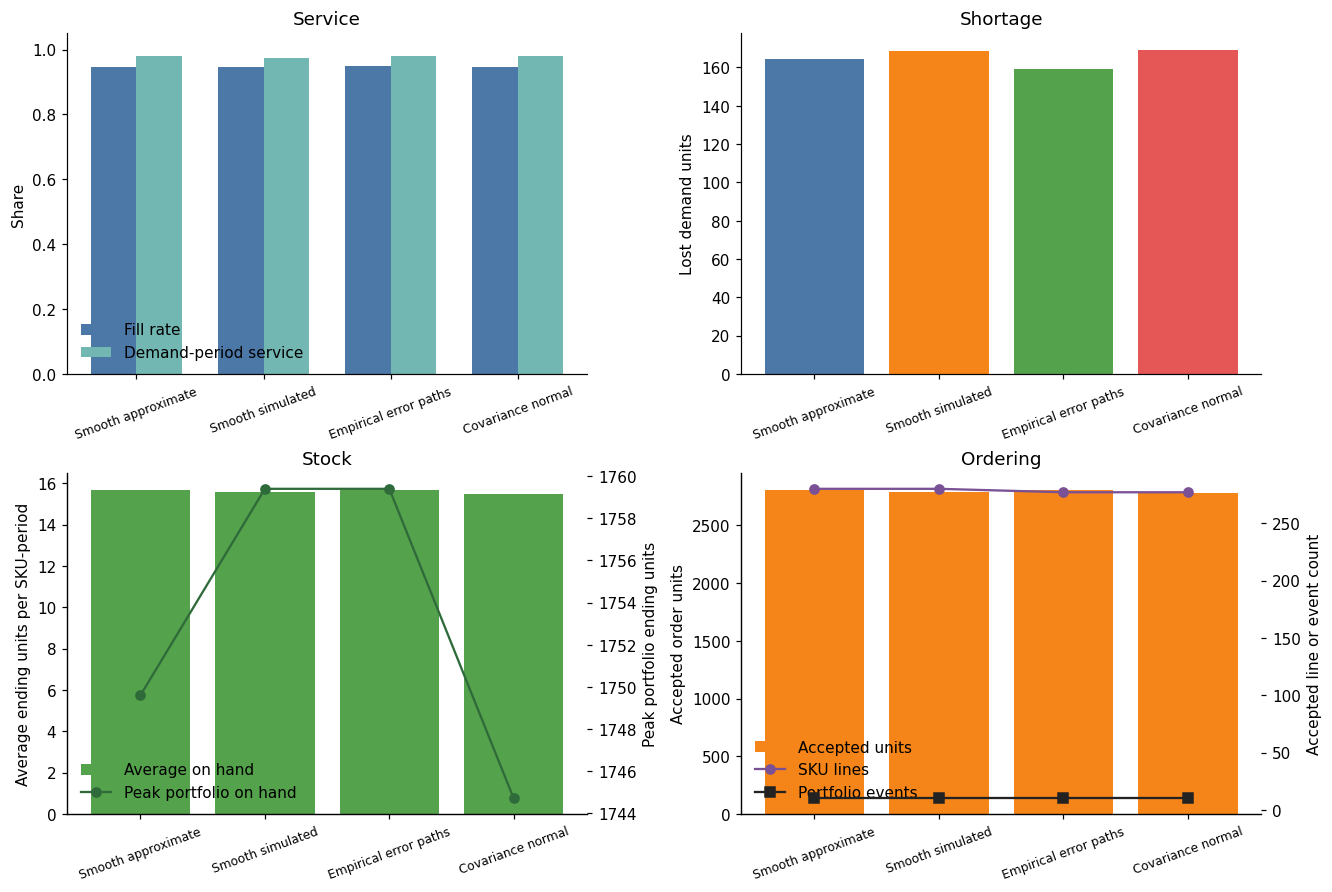

In [27]:
operational_plot = all_in_costs.set_index('method').loc[method_order].reset_index()
fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout='constrained')
x = np.arange(len(method_order))
width = 0.36

axes[0, 0].bar(x - width/2, operational_plot.fill_rate, width, label='Fill rate', color='#4C78A8')
axes[0, 0].bar(x + width/2, operational_plot.demand_period_service_level, width, label='Demand-period service', color='#72B7B2')
axes[0, 0].set(title='Service', ylabel='Share', ylim=(0, 1.05)); axes[0, 0].legend(frameon=False, loc='lower left')

axes[0, 1].bar(x, operational_plot.lost_sales_units, color=[method_colors[m] for m in method_order])
axes[0, 1].set(title='Shortage', ylabel='Lost demand units')

stock_bars = axes[1, 0].bar(x, operational_plot.avg_on_hand, label='Average on hand', color='#54A24B')
stock_peak_axis = axes[1, 0].twinx()
stock_peak_line = stock_peak_axis.plot(x, operational_plot.peak_ending_on_hand, marker='o', color='#2F6B3A', label='Peak portfolio on hand')[0]
axes[1, 0].set(title='Stock', ylabel='Average ending units per SKU-period')
stock_peak_axis.set_ylabel('Peak portfolio ending units')
axes[1, 0].legend([stock_bars, stock_peak_line], ['Average on hand', 'Peak portfolio on hand'], frameon=False, loc='lower left')

order_bars = axes[1, 1].bar(x, operational_plot.order_units, label='Accepted units', color='#F58518')
order_count_axis = axes[1, 1].twinx()
sku_line = order_count_axis.plot(x, operational_plot.sku_order_line_count, marker='o', color='#7A5195', label='SKU lines')[0]
event_line = order_count_axis.plot(x, operational_plot.order_event_count, marker='s', color='#222222', label='Portfolio events')[0]
axes[1, 1].set(title='Ordering', ylabel='Accepted order units')
order_count_axis.set_ylabel('Accepted line or event count')
axes[1, 1].legend([order_bars, sku_line, event_line], ['Accepted units', 'SKU lines', 'Portfolio events'], frameon=False, loc='lower left')

for ax in axes.flat:
    ax.set_xticks(x, method_order, rotation=20, fontsize=8)
plt.show()

The four views explain the cost ranking in operational terms. Fill rate is unit-weighted, demand-period service counts positive-demand SKU-days without shortage, stock measures end-of-period holdings, and ordering distinguishes accepted units from SKU lines and portfolio events.

## 27. Validate Stage 1's scientific and accounting identities

The final executable checks connect the tutorial claims to live objects. They verify exact fit cardinality and leakage boundaries, four-method fit reuse, direct cumulative formulas, schedule dates, shared demand and opening fingerprints, callback/constraint order, accepted breakage evidence, event balance identities, and both ordinary and all-in cost sums. Any disagreement stops execution rather than being repaired.

In [28]:
# Every origin has exactly one independent fit for each of the 100 SKUs.
assert len(skus) == 100 and len(fit_registry) == 100 * len(calibration_origins)
assert not fit_registry.duplicated(['unique_id', 'forecast_origin']).any()
assert fit_registry.observed_through_date.eq(fit_registry.forecast_origin).all()
assert target_catalogue.groupby('fit_id').size().eq(4).all()

# Direct target formulas and complete provenance remain internally consistent.
assert target_catalogue.groupby(['method', 'forecast_origin']).unique_id.nunique().eq(100).all()
assert target_catalogue.target_end_date.eq(target_catalogue.forecast_origin + pd.Timedelta(days=4)).all()
assert target_catalogue.target_probability.eq(probability).all()
empirical_rows = target_catalogue[target_catalogue.method.eq('Empirical error paths')]
covariance_rows = target_catalogue[target_catalogue.method.eq('Covariance normal')]
assert np.allclose(empirical_rows.cumulative_target, empirical_rows.cumulative_mean + empirical_rows.empirical_error_quantile)
assert np.allclose(covariance_rows.safety_stock, norm.ppf(probability) * np.sqrt(covariance_rows.covariance_sum_variance))

# Schedules update only on review dates through February 20.
expected_periods = list(range(2, 21, 2))
assert all(list(schedule) == expected_periods for schedule in policy_schedules)
assert all(snapshot.get_target_metadata()['forecast_origin'][:10] == str((opening_date + pd.Timedelta(days=period)).date()) for schedule in policy_schedules for period, snapshot in schedule.items())

# Comparison branches share demand and opening inputs but retain isolated results.
manifests = [comparison[method].run_manifest for method in method_order]
assert len({manifest['demand_source']['sha256'] for manifest in manifests}) == 1
assert len({manifest['opening_inventory']['sha256'] for manifest in manifests}) == 1
assert all(manifest['demand_source']['materialized_once_for_comparison'] for manifest in manifests)
assert all(manifest['run_settings']['policy_update_periods'] == expected_periods for manifest in manifests)

# Callback and constraint order are manifest evidence, not inferred from prose.
expected_callbacks = ['PriorityExpedite', 'SupplierBatchGate', 'ReceivingInspectionBreakage']
assert all([entry['class'] for entry in manifest['run_settings']['callbacks']] == expected_callbacks for manifest in manifests)
assert all([entry['class'] for entry in manifest['run_settings']['order_constraints']['constraints']] == ['MinimumOrderQuantity', 'OrderMultiple', 'MaximumOrderQuantity'] for manifest in manifests)

# Canonical flows and accepted callback evidence reconcile in every branch.
for method in method_order:
    scoring = comparison[method].to_event_frame(window='scoring')
    assert np.allclose(scoring.demand, scoring.fulfilled_units + scoring.shortage_units)
    physical_end = scoring.starting_on_hand + scoring.received_units - scoring.fulfilled_units - scoring.backorders_fulfilled - scoring.expired_units + scoring.inventory_adjustment_units
    assert np.allclose(scoring.ending_on_hand, physical_end)
    assert np.isclose(-scoring.inventory_adjustment_units.clip(upper=0).sum(), breakage_costs.set_index('method').loc[method, 'accepted_breakage_units'])

# Ordinary and intervention component identities define the selection objective.
assert np.allclose(all_in_costs.total_cost, all_in_costs[['holding_cost', 'shortage_cost', 'ordering_cost', 'purchase_cost']].sum(axis=1))
assert np.allclose(all_in_costs.all_in_total_cost, all_in_costs[cost_components].sum(axis=1))
assert selected_method == str(all_in_costs.sort_values(['all_in_total_cost', 'method']).iloc[0].method)
print('Stage 1 validation passed: 100 SKUs, 1,200 independent fits, four shared-demand replays, and all cost identities.')

Stage 1 validation passed: 100 SKUs, 1,200 independent fits, four shared-demand replays, and all cost identities.


All Stage 1 checks passed in the executed notebook. The selected method and its complete calibration evidence are now ready for review. Stage 2 remains outside this pass: no final-test forecast, policy schedule, inventory replay, metric, or selection has been created, and Notebook 08 is not marked complete.

In [29]:
# # Active only in this temporary copy; the original notebook is never executed.
# import hashlib
# import json
# from datetime import datetime, timezone
#
# checkpoint_path = Path('examples/notebooks/data/m5/notebook08_covariance_normal_checkpoint_2016-02-28.json')
# branch_name = 'Covariance normal'
# branch_result = comparison[branch_name]
# terminal = branch_result.inventory.get_dataframe().copy()
# active_origin = pd.Timestamp('2016-02-20')
# active_targets = target_catalogue[
#     target_catalogue.method.eq(branch_name)
#     & target_catalogue.forecast_origin.eq(active_origin)
# ].copy().sort_values('unique_id')
# active_policy = policy_schedules[method_order.index(branch_name)][20]
# manifest = branch_result.run_manifest
#
# def json_ready(value):
#     if isinstance(value, dict):
#         return {str(key): json_ready(item) for key, item in value.items()}
#     if isinstance(value, (list, tuple, np.ndarray)):
#         return [json_ready(item) for item in value]
#     if isinstance(value, (pd.Timestamp, datetime)):
#         return value.isoformat()
#     if isinstance(value, (np.integer,)):
#         return int(value)
#     if isinstance(value, (np.floating,)):
#         return float(value)
#     if isinstance(value, (np.bool_,)):
#         return bool(value)
#     if pd.isna(value):
#         return None
#     return value
#
# inventory_columns = [
#     'unique_id', 'on_hand', 'backorders', 'in_transit', 'period', 'date',
#     'is_review_period', 'target_level', 'safety_stock', 'latest_order',
#     'latest_received', 'latest_incoming_demand', 'latest_fulfilled',
#     'latest_shortage', 'latest_backorders_fulfilled',
# ]
# inventory_rows = [json_ready(row) for row in terminal[inventory_columns].to_dict('records')]
# target_columns = [
#     'unique_id', 'forecast_origin', 'observed_through_date', 'forecast_frequency',
#     'protection_horizon', 'target_end_date', 'target_probability',
#     'cumulative_mean', 'covariance_sum_variance', 'safety_stock',
#     'cumulative_target', 'target_formula', 'representation',
#     'policy_target_source', 'ets_model', 'smooth_version', 'error_path_rows',
# ]
# checkpoint = {
#     'schema_version': 'pyforia.notebook08.covariance_normal_checkpoint.v1',
#     'checkpoint': {
#         'as_of_date': '2016-02-28',
#         'period': 28,
#         'allow_backorders': False,
#         'shortage_mode': 'lost_sales',
#         'sku_count': 100,
#         'pipeline_slots': 2,
#     },
#     'inventory_rows': inventory_rows,
#     'active_policy': {
#         'branch_name': branch_name,
#         'class': type(active_policy).__name__,
#         'lead_time': active_policy.lead_time,
#         'review_period': active_policy.review_period,
#         'service_level': active_policy.service_level,
#         'allow_backorders': active_policy.allow_backorders,
#         'target_metadata': json_ready(active_policy.get_target_metadata()),
#         'target_rows': [json_ready(row) for row in active_targets[target_columns].to_dict('records')],
#     },
#     'generation': {
#         'generated_at_utc': datetime.now(timezone.utc).isoformat(),
#         'source_notebook': 'examples/notebooks/08_full_operational_experiment.ipynb',
#         'source_notebook_sha256': hashlib.sha256(Path('examples/notebooks/08_full_operational_experiment.ipynb').read_bytes()).hexdigest(),
#         'branch_name': branch_name,
#         'run_id': manifest.get('run_id'),
#         'run_manifest': json_ready(manifest),
#         'operational_configuration': {
#             'period_frequency': period_frequency,
#             'lead_time': lead_time,
#             'review_period': review_period,
#             'service_level': probability,
#             'protection_horizon': protection_horizon,
#             'allow_backorders': False,
#             'initial_decision': 'none',
#             'callbacks': json_ready(manifest['run_settings']['callbacks']),
#             'order_constraints': json_ready(manifest['run_settings']['order_constraints']),
#             'calibration_windows': {
#                 'warmup_periods': warmup_periods,
#                 'scoring_periods': scoring_periods,
#                 'settlement_periods': settlement_periods,
#                 'order_during_settlement': False,
#             },
#             'cost_context': json_ready(cost_context),
#         },
#         'source_commit': json_ready(manifest.get('package', {})),
#         'dependency_versions': json_ready(manifest.get('dependencies', {})) | {'smooth': smooth_version, 'scipy': metadata.version('scipy')},
#         'demand_fingerprint': manifest['demand_source']['sha256'],
#     },
# }
#
# # Fail closed before writing the artifact.
# assert len(inventory_rows) == 100
# assert {row['unique_id'] for row in inventory_rows} == set(skus)
# assert all(row['period'] == 28 and row['date'][:10] == '2016-02-28' for row in inventory_rows)
# assert all(len(row['in_transit']) == 2 for row in inventory_rows)
# for row in inventory_rows:
#     values = [row['on_hand'], row['backorders'], *row['in_transit']]
#     assert np.isfinite(values).all() and np.asarray(values).min() >= 0
# assert len(active_targets) == 100 and set(active_targets.unique_id) == set(skus)
# assert active_policy.get_target_metadata()['forecast_origin'][:10] == '2016-02-20'
# assert active_targets.observed_through_date.eq(active_targets.forecast_origin).all()
#
# canonical = json.dumps(checkpoint, sort_keys=True, separators=(',', ':'), allow_nan=False)
# checkpoint['checkpoint_fingerprint'] = hashlib.sha256(canonical.encode()).hexdigest()
# recomputed = hashlib.sha256(json.dumps(
#     {key: value for key, value in checkpoint.items() if key != 'checkpoint_fingerprint'},
#     sort_keys=True, separators=(',', ':'), allow_nan=False,
# ).encode()).hexdigest()
# assert recomputed == checkpoint['checkpoint_fingerprint']
# checkpoint_path.write_text(json.dumps(checkpoint, indent=2, sort_keys=True, allow_nan=False) + '\n')
# print(f'Wrote {checkpoint_path} with {len(inventory_rows)} SKUs and fingerprint {recomputed}')
